# Student Success Predictor:

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv("student_data.csv")

print("Sample Rows")
print(df.head())

Sample Rows
   Study Hours  Attendance  Previous Score Internet  Sleep Hours Pass
0          6.6        41.5            49.3      Yes          4.7   No
1          7.5        72.7            71.3      Yes          4.1  Yes
2          5.3        41.6            43.9       No          5.1   No
3          8.2        40.4            86.4       No          5.7  Yes
4          9.6        60.2            36.5      Yes          5.8  Yes


In [4]:
print("DataSet Shape")
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print("DataSet Info")
print(df.info())

print("Summary Statistics")
print(df.describe(include='all'))

print("Missing Values") 
print(df.isnull().sum()) 

DataSet Shape
Rows: 50, Columns: 6
DataSet Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Study Hours     50 non-null     float64
 1   Attendance      50 non-null     float64
 2   Previous Score  50 non-null     float64
 3   Internet        50 non-null     object 
 4   Sleep Hours     50 non-null     float64
 5   Pass            50 non-null     object 
dtypes: float64(4), object(2)
memory usage: 2.5+ KB
None
Summary Statistics
        Study Hours  Attendance  Previous Score Internet  Sleep Hours Pass
count     50.000000   50.000000       50.000000       50    50.000000   50
unique          NaN         NaN             NaN        2          NaN    2
top             NaN         NaN             NaN      Yes          NaN  Yes
freq            NaN         NaN             NaN       27          NaN   34
mean       5.704000   64.006000       6

In [5]:
# Label Encoder 
print("Missing Values In Each Column\n", df.isnull().sum())

le = LabelEncoder() # If you have 2 categorical columns use label encoder and if more than 2 then use get.dummies()
df['Internet'] = le.fit_transform(df['Internet']) # Yes or No
df['Pass'] = le.fit_transform(df['Pass'])

print("After Encoding\n", df) # Double Check After Encoding
print("Data Types After Cleaning\n", df.dtypes)

Missing Values In Each Column
 Study Hours       0
Attendance        0
Previous Score    0
Internet          0
Sleep Hours       0
Pass              0
dtype: int64
After Encoding
     Study Hours  Attendance  Previous Score  Internet  Sleep Hours  Pass
0           6.6        41.5            49.3         1          4.7     0
1           7.5        72.7            71.3         1          4.1     1
2           5.3        41.6            43.9         0          5.1     0
3           8.2        40.4            86.4         0          5.7     1
4           9.6        60.2            36.5         1          5.8     1
5           3.0        42.6            62.2         1          8.9     0
6           5.7        89.8            73.3         0          6.9     1
7           0.9        53.7            50.3         1          8.3     0
8           4.1        67.2            88.4         1          5.9     1
9           3.0        96.2            75.4         1          6.7     1
10          4.9  

Classification Report
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.88      0.78      0.82         9

    accuracy                           0.70        10
   macro avg       0.44      0.39      0.41        10
weighted avg       0.79      0.70      0.74        10



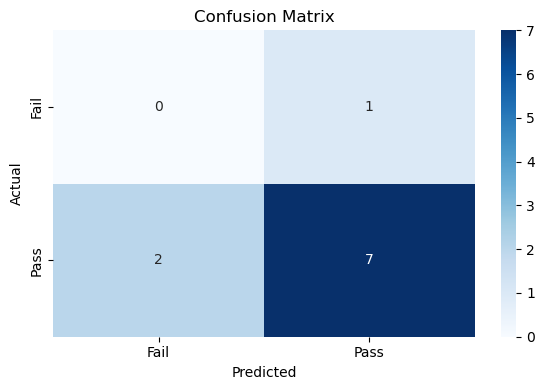

----Predict Your Result----


Enter Study Hours:  9
Enter Attendance:  95
Enter Previous Score:  90
Enter Sleeping Hours:  9


Prediction Based On Input: Pass


D:\Ananconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [6]:
###### Feature Scaling:

features = ['Study Hours','Attendance', 'Previous Score', 'Sleep Hours']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

x = df_scaled[features]
y = df_scaled['Pass']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Classification Report\n", classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)
plt.xlabel("Predicted"),
plt.ylabel("Actual")
plt.title("Confusion Matrix"),
plt.tight_layout()
plt.show()

print("----Predict Your Result----")
try:
    study_hours = float(input("Enter Study Hours: "))
    attendance = float(input("Enter Attendance: "))
    prev_score = float(input("Enter Previous Score: "))
    sleep_hours = float(input("Enter Sleeping Hours: "))

    user_input_df = pd.DataFrame([{
        'Study Hours': study_hours,
        'Attendance': attendance,
        "Previous Score": prev_score,
        'Sleep Hours': sleep_hours
    }])

    user_input_scaled = scaler.transform(user_input_df)

    prediction = model.predict(user_input_scaled)[0]

    result = "Pass" if prediction ==1 else "Fail"
    print(f"Prediction Based On Input: {result}")
except Exception as e:
    print("An Error Occured Due To Invalid Data Type", e )